## Setup — Import libraries


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data   # provides sample images (camera, checkerboard, coins, ...)

# Make plots show inside the notebook
%matplotlib inline

## Task 1 — Canny Edge Detection


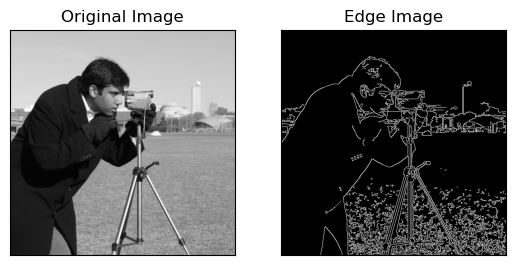

In [2]:
img = data.camera()                                  

edges = cv2.Canny(img, 100, 200)

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap='gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

## Task 2 — Harris Corner Detection


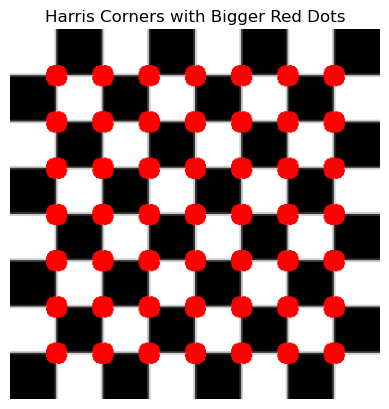

In [3]:
board = data.checkerboard()                        
image = cv2.cvtColor(board, cv2.COLOR_GRAY2BGR)
image = cv2.resize(image, (400, 400), interpolation=cv2.INTER_NEAREST)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Harris Corner Detection
harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)   # to mark corners more clearly

# Threshold for detecting strong corners
threshold = 0.01 * harris.max()
corner_coords = np.argwhere(harris > threshold)

# Draw larger red dots (radius = 7)
for y, x in corner_coords:
    cv2.circle(image, (x, y), radius=7, color=(0, 0, 255), thickness=-1)  # -1 = filled

# Display
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners with Bigger Red Dots')
plt.axis('off')
plt.show()

## Simple (Global) Binary Thresholding


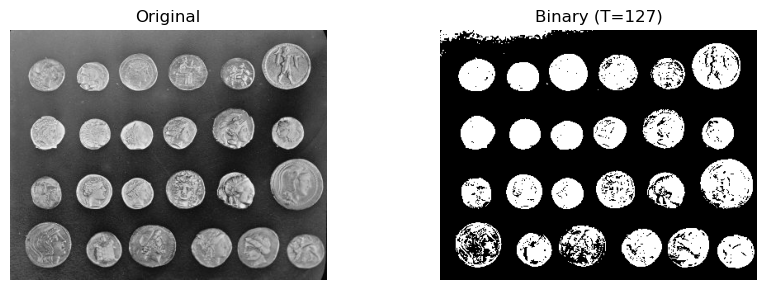

(None, None)

In [4]:
img = data.coins()

T = 127
_, binary = cv2.threshold(img, T, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(binary, cmap='gray'), plt.title(f'Binary (T={T})'), plt.axis('off')
plt.tight_layout(), plt.show()

## Q1 — Otsu's Thresholding (Assessment Task)
Otsu picks `T` **automatically** by maximizing the between-class variance — assumes the histogram has two peaks (foreground + background).

show the original image, its histogram, and the thresholded image.

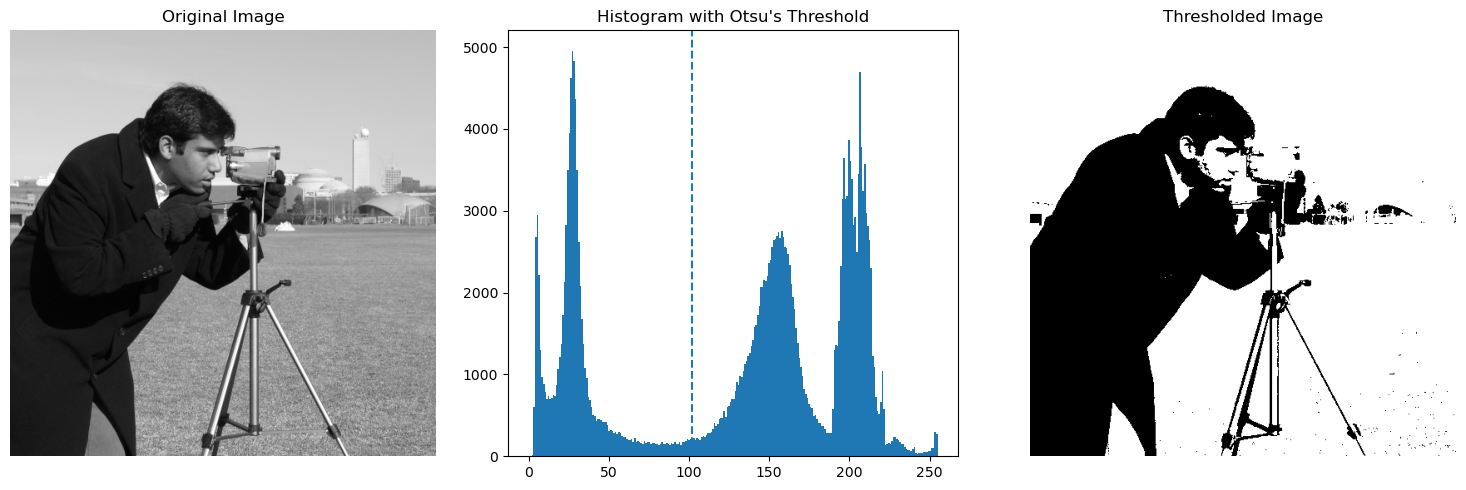

Otsu Threshold Value: 102


In [5]:
from skimage import data, filters
import matplotlib.pyplot as plt

image = data.camera()

threshold = filters.threshold_otsu(image)

binary = image > threshold

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].hist(image.ravel(), bins=256)
axes[1].axvline(threshold, linestyle='--')
axes[1].set_title("Histogram with Otsu's Threshold")

axes[2].imshow(binary, cmap='gray')
axes[2].set_title('Thresholded Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("Otsu Threshold Value:", threshold)

---
## Summary table

| Technique | Category | What it finds | OpenCV function |
|---|---|---|---|
| Canny | Edge detection | Thin connected edges | `cv2.Canny` |
| Sobel | Edge detection | Gradient magnitude (thick) | `cv2.Sobel` |
| Laplacian | Edge detection | Zero-crossings (2nd deriv) | `cv2.Laplacian` |
| Harris | Feature extraction | Corners | `cv2.cornerHarris` |
| Shi-Tomasi | Feature extraction | Corners (improved) | `cv2.goodFeaturesToTrack` |
| Simple threshold | Segmentation | Fixed-`T` binary mask | `cv2.threshold` |
| Otsu | Segmentation | Auto bimodal threshold | `cv2.threshold` + `THRESH_OTSU` |
| Adaptive threshold | Segmentation | Local-`T` binary mask | `cv2.adaptiveThreshold` |

